# FX Val EDA — Gym99 Validation Split
Mirrors `FX_train_eda.ipynb` but scoped to the validation split.
Set `APPARATUS` in the config cell to match your training run.

In [12]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/schizocatto/Yolo-ST-GCN.git'
BRANCH   = 'experiment-bonestream'
REPO_DIR = Path('/content/Yolo-ST-GCN') if IN_COLAB else Path(os.getcwd())

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'huggingface_hub', 'scipy', 'scikit-learn'], check=True)
    if not REPO_DIR.exists():
        subprocess.run(['git', 'clone', '-b', BRANCH, '--single-branch',
                        REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', 'origin', BRANCH], check=True)

os.chdir(str(REPO_DIR))
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print('Working dir:', os.getcwd())

Working dir: /content/Yolo-ST-GCN


In [13]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
SEED = 42
np.random.seed(SEED)

In [14]:
if IN_COLAB:
    GYM288_PKL = '/content/Gym288-skeleton/gym_288_skeleton.pkl'
    GYM99_PKL  = '/content/Gym99-from-Gym288/gym99_from_gym288.pkl'
else:
    GYM288_PKL = 'data/Gym288-skeleton/gym_288_skeleton.pkl'
    GYM99_PKL  = 'data/Gym99-from-Gym288/gym99_from_gym288.pkl'

In [15]:
if IN_COLAB and not Path(GYM288_PKL).exists():
    from huggingface_hub import snapshot_download
    dl = Path(GYM288_PKL).parent
    dl.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id='Lozumi/Gym288-skeleton', repo_type='dataset',
                      local_dir=str(dl), local_dir_use_symlinks=False)
    GYM288_PKL = str(sorted(dl.rglob('*.pkl'))[0])
print('Gym288:', GYM288_PKL)

Gym288: /content/Gym288-skeleton/gym_288_skeleton.pkl


In [16]:
if not Path(GYM99_PKL).exists():
    from src.gym99_builder import build_gym99_from_gym288_pickle
    Path(GYM99_PKL).parent.mkdir(parents=True, exist_ok=True)
    stats = build_gym99_from_gym288_pickle(GYM288_PKL, GYM99_PKL)
    print('Build stats:', stats)

with open(GYM99_PKL, 'rb') as f:
    raw99 = pickle.load(f)

anns99 = raw99['annotations']
split99 = raw99['split']
train_ids99 = set(split99.get('train', []))
test_ids99  = set(split99.get('test',  []))
print(f'Gym99  total={len(anns99)}  train={len(train_ids99)}  test={len(test_ids99)}')

Gym99  total=36665  train=27624  test=9041


In [17]:
from src.gym99_dataset import build_gym99_data_tensors

data, labels, flags, raw_frame_counts_list, video_ids = build_gym99_data_tensors(
    dataset_path=GYM99_PKL,
    joint_spec_name='coco18',
    split='all',
    keep_unknown_split=False,
)
raw_frame_counts = np.array(raw_frame_counts_list)
print(f'Tensor shape: {data.shape}  dtype={data.dtype}')
print(f'Total: {len(data)}  train={(flags==1).sum()}  test={(flags==0).sum()}')

Tensor shape: (36665, 2, 48, 18, 1)  dtype=float32
Total: 36665  train=27624  test=9041


---
## Config — edit here to match your training run

In [18]:
# ── Edit to match your train_gym99.py arguments ───────────────
APPARATUS = 'FX'    # 'all' | 'VT' | 'FX' | 'BB' | 'UB'
# ─────────────────────────────────────────────────────────────

In [19]:
APPARATUS_RANGES = {'VT': (0, 5), 'FX': (6, 40), 'BB': (41, 73), 'UB': (74, 98)}

train_mask = flags == 1
test_mask  = flags == 0

X_train, y_train = data[train_mask], labels[train_mask]
X_val,   y_val   = data[test_mask],  labels[test_mask]
fc_train = raw_frame_counts[train_mask]
fc_val   = raw_frame_counts[test_mask]
ids_train = [video_ids[i] for i, m in enumerate(train_mask) if m]
ids_val   = [video_ids[i] for i, m in enumerate(test_mask)  if m]

apparatus_label_offset = 0
if APPARATUS != 'all':
    lo, hi = APPARATUS_RANGES[APPARATUS]
    apparatus_label_offset = lo

    def _filter(X, y, fc, ids):
        mask = (y >= lo) & (y <= hi)
        return X[mask], y[mask] - lo, fc[mask], [ids[i] for i, m in enumerate(mask) if m]

    X_train, y_train, fc_train, ids_train = _filter(X_train, y_train, fc_train, ids_train)
    X_val,   y_val,   fc_val,   ids_val   = _filter(X_val,   y_val,   fc_val,   ids_val)
    print(f'[apparatus={APPARATUS}] global labels [{lo}, {hi}] → local [0, {hi - lo}]')

num_classes = int(y_train.max()) + 1
print(f'train={len(X_train)}  val={len(X_val)}  num_classes={num_classes}')

[apparatus=FX] global labels [6, 40] → local [0, 34]
train=5824  val=2411  num_classes=35


---
## 1. Val Split Overview

In [20]:
def gini(values):
    v = np.sort(np.array(values, dtype=float))
    n = len(v)
    idx = np.arange(1, n + 1)
    return float((2 * np.dot(idx, v)) / (n * v.sum()) - (n + 1) / n)

def effective_n(values):
    v = np.array(values, dtype=float)
    p = v / v.sum()
    return float(np.exp(-np.sum(p * np.log(p + 1e-12))))

counts_va  = Counter(y_val.tolist())
counts_tr  = Counter(y_train.tolist())
vals_val   = np.array(sorted(counts_va.values(), reverse=True))
classes    = np.arange(num_classes)

global_range = (
    f'[{apparatus_label_offset}, {apparatus_label_offset + num_classes - 1}]'
    if APPARATUS != 'all' else '[0, 98]'
)

rows = [{
    'Apparatus':          APPARATUS,
    'Global label range': global_range,
    'Local classes':      num_classes,
    'Val samples':        len(X_val),
    'Train samples':      len(X_train),
    'Min/class (val)':    int(vals_val.min()),
    'Median/class (val)': int(np.median(vals_val)),
    'Max/class (val)':    int(vals_val.max()),
    'Imbalance ratio':    f'{vals_val.max() / max(vals_val.min(), 1):.0f}x',
    'Gini (val)':         f'{gini(vals_val):.3f}',
    'Effective N (val)':  f'{effective_n(vals_val):.1f} / {num_classes}',
}]
display(pd.DataFrame(rows).set_index('Apparatus').T)

Apparatus,FX
Global label range,"[6, 40]"
Local classes,35
Val samples,2411
Train samples,5824
Min/class (val),24
Median/class (val),56
Max/class (val),183
Imbalance ratio,8x
Gini (val),0.306
Effective N (val),30.1 / 35


---
## 2. Class Distribution — Val vs Train

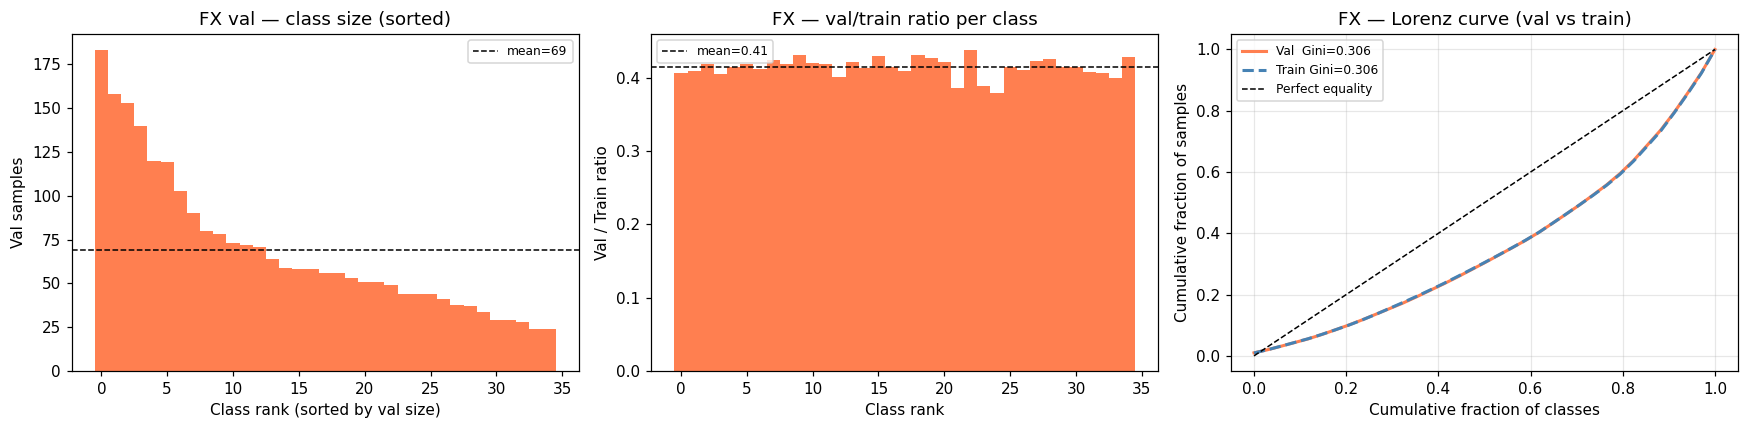

Val   Gini=0.306  EffN=30.1/35  <5: 0  <10: 0
Train Gini=0.306  EffN=30.0/35


In [21]:
va_counts = np.array([counts_va.get(c, 0) for c in classes])
tr_counts = np.array([counts_tr.get(c, 0) for c in classes])
sort_idx  = np.argsort(va_counts)[::-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Val class sizes sorted
ax = axes[0]
ax.bar(np.arange(num_classes), va_counts[sort_idx], color='coral', width=1.0)
ax.axhline(va_counts.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={va_counts.mean():.0f}')
ax.set_xlabel('Class rank (sorted by val size)')
ax.set_ylabel('Val samples')
ax.set_title(f'{APPARATUS} val — class size (sorted)')
ax.legend(fontsize=8)

# Val vs train ratio per class
ax = axes[1]
ratio = va_counts / np.maximum(tr_counts, 1)
ax.bar(np.arange(num_classes), ratio[sort_idx], color='coral', width=1.0)
ax.axhline(ratio.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={ratio.mean():.2f}')
ax.set_xlabel('Class rank')
ax.set_ylabel('Val / Train ratio')
ax.set_title(f'{APPARATUS} — val/train ratio per class')
ax.legend(fontsize=8)

# Lorenz curve — val
ax = axes[2]
v = np.sort(va_counts)
cumulative = np.cumsum(v) / v.sum()
ax.plot(np.linspace(0, 1, len(v)), cumulative, color='coral', linewidth=2,
        label=f'Val  Gini={gini(v):.3f}')
v2 = np.sort(tr_counts)
cumulative2 = np.cumsum(v2) / v2.sum()
ax.plot(np.linspace(0, 1, len(v2)), cumulative2, color='steelblue', linewidth=2,
        linestyle='--', label=f'Train Gini={gini(v2):.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
ax.set_xlabel('Cumulative fraction of classes')
ax.set_ylabel('Cumulative fraction of samples')
ax.set_title(f'{APPARATUS} — Lorenz curve (val vs train)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Val   Gini={gini(va_counts):.3f}  EffN={effective_n(va_counts):.1f}/{num_classes}  '
      f'<5: {(va_counts<5).sum()}  <10: {(va_counts<10).sum()}')
print(f'Train Gini={gini(tr_counts):.3f}  EffN={effective_n(tr_counts):.1f}/{num_classes}')

---
## 3. Val Split Quality

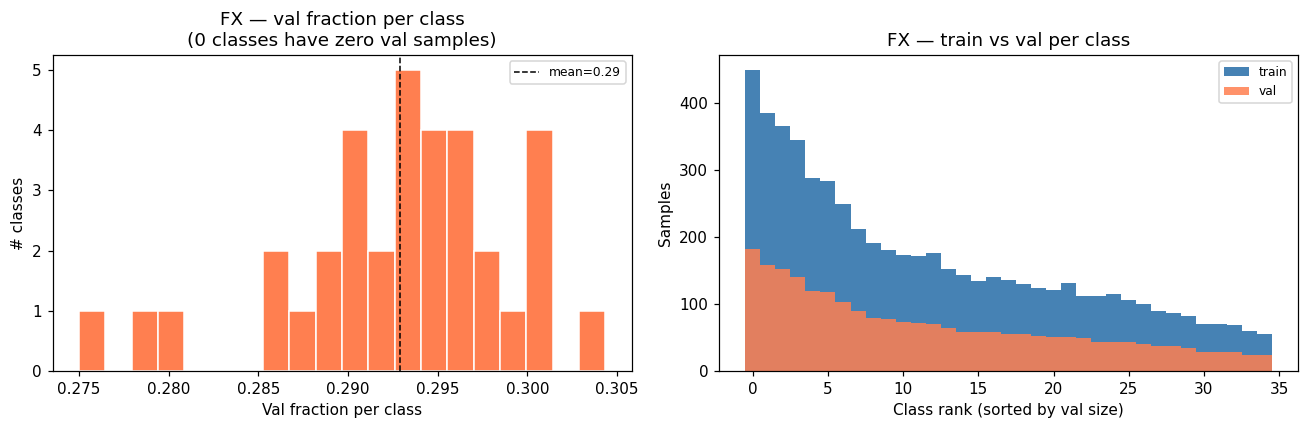

zero-val classes: 0/35  mean_val_frac=0.293  std=0.006
frame_dir overlap train∩val: 0  ✓ clean


In [22]:
# Per-class val fraction and train/val symmetry
val_fracs  = []
zero_val   = 0
for c in classes:
    tr = counts_tr.get(c, 0)
    va = counts_va.get(c, 0)
    total = tr + va
    val_fracs.append(va / total if total > 0 else 0.0)
    if va == 0:
        zero_val += 1
val_fracs = np.array(val_fracs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(val_fracs, bins=20, color='coral', edgecolor='white')
ax.axvline(val_fracs.mean(), color='black', linestyle='--', linewidth=1,
           label=f'mean={val_fracs.mean():.2f}')
ax.set_xlabel('Val fraction per class')
ax.set_ylabel('# classes')
ax.set_title(f'{APPARATUS} — val fraction per class\n({zero_val} classes have zero val samples)')
ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(num_classes)
ax.bar(x, tr_counts[sort_idx], label='train', color='steelblue', width=1.0)
ax.bar(x, va_counts[sort_idx], label='val',   color='coral',     width=1.0, alpha=0.85)
ax.set_xlabel('Class rank (sorted by val size)')
ax.set_ylabel('Samples')
ax.set_title(f'{APPARATUS} — train vs val per class')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'zero-val classes: {zero_val}/{num_classes}  '
      f'mean_val_frac={val_fracs.mean():.3f}  std={val_fracs.std():.3f}')

overlap = set(ids_train) & set(ids_val)
print(f'frame_dir overlap train∩val: {len(overlap)}  '
      + ('⚠ LEAKAGE' if overlap else '✓ clean'))

---
## 4. Frame Count Distribution — Val

Val  min=2  median=36  mean=38.7  max=137  shorter_than_64: 2283 (94.7%)
Train  min=2  median=35  mean=37.6  max=174  shorter_than_64: 5573 (95.7%)


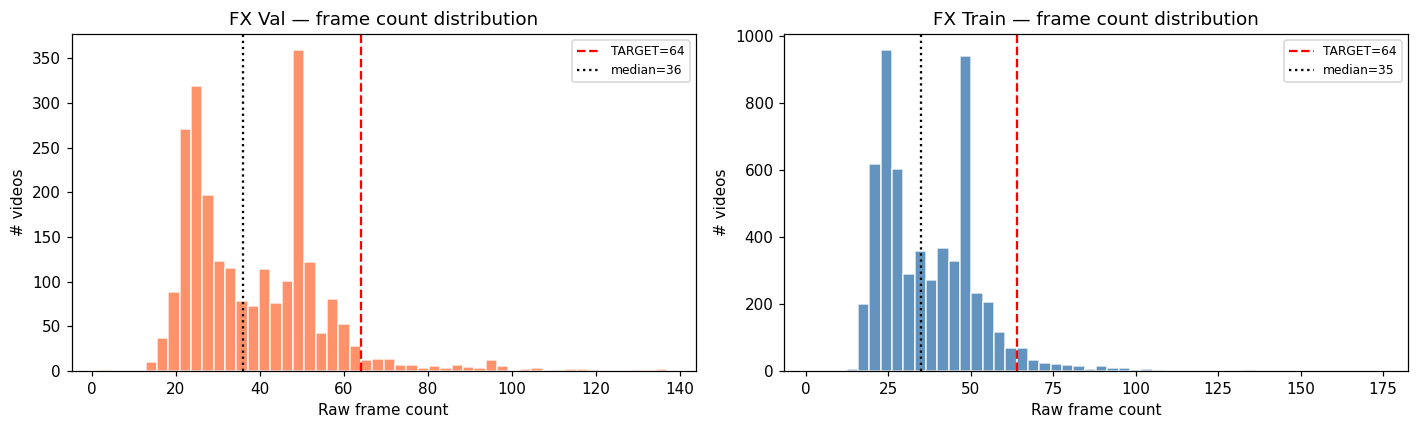

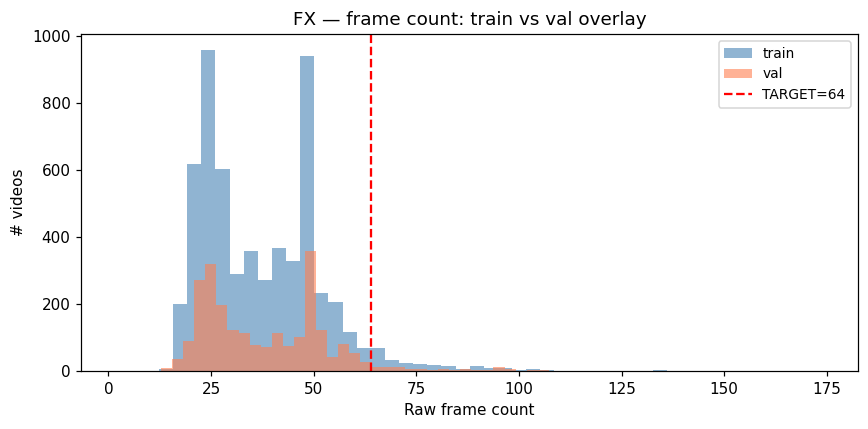

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, fc, color) in zip(axes, [
    ('Val',   fc_val,   'coral'),
    ('Train', fc_train, 'steelblue'),
]):
    ax.hist(fc, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(64, color='red',   linestyle='--', linewidth=1.5, label='TARGET=64')
    ax.axvline(np.median(fc), color='black', linestyle=':', linewidth=1.5,
               label=f'median={int(np.median(fc))}')
    ax.set_xlabel('Raw frame count')
    ax.set_ylabel('# videos')
    ax.set_title(f'{APPARATUS} {name} — frame count distribution')
    ax.legend(fontsize=8)
    print(f'{name}  min={fc.min()}  median={int(np.median(fc))}  '
          f'mean={fc.mean():.1f}  max={fc.max()}  '
          f'shorter_than_64: {(fc<64).sum()} ({(fc<64).mean():.1%})')

plt.tight_layout()
plt.show()

# Overlay val vs train frame count distributions
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fc_train, bins=50, color='steelblue', edgecolor='none', alpha=0.6, label='train')
ax.hist(fc_val,   bins=50, color='coral',     edgecolor='none', alpha=0.6, label='val')
ax.axvline(64, color='red', linestyle='--', linewidth=1.5, label='TARGET=64')
ax.set_xlabel('Raw frame count')
ax.set_ylabel('# videos')
ax.set_title(f'{APPARATUS} — frame count: train vs val overlay')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Skeleton Coordinate Analysis — Val

In [ ]:
print(f'Processed X_val: {X_val.shape}  min={X_val.min():.3f}  max={X_val.max():.3f}')

rng = np.random.default_rng(SEED)

if APPARATUS != 'all':
    lo_g = apparatus_label_offset
    hi_g = apparatus_label_offset + num_classes - 1
    val_anns = [a for a in anns99
                if lo_g <= int(a['label']) <= hi_g
                and str(a['frame_dir']) in test_ids99]
else:
    val_anns = [a for a in anns99 if str(a['frame_dir']) in test_ids99]

sample_idx = np.arange(len(val_anns))

all_kpts = []
for i in sample_idx:
    kp = np.asarray(val_anns[i]['keypoint'], dtype=np.float32)
    if kp.ndim == 4:
        kp = kp[0]
    all_kpts.append(kp.reshape(-1, kp.shape[-2], 2)[:, :17, :])
all_kpts = np.concatenate(all_kpts, axis=0)

COCO17_NAMES = ['nose','l_eye','r_eye','l_ear','r_ear',
                'l_sho','r_sho','l_elb','r_elb','l_wri','r_wri',
                'l_hip','r_hip','l_kne','r_kne','l_ank','r_ank']
COCO18_NAMES = COCO17_NAMES + ['center']

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()
for j in range(17):
    x = all_kpts[:, j, 0]
    y = all_kpts[:, j, 1]
    valid = (x > 0) & (y > 0)
    axes[j].hist2d(x[valid], y[valid], bins=40, cmap='hot')
    axes[j].invert_yaxis()
    axes[j].set_title(COCO17_NAMES[j], fontsize=7)
    axes[j].axis('off')
for j in range(17, len(axes)):
    axes[j].axis('off')
fig.suptitle(f'Per-joint 2D heatmap — {APPARATUS} val ({len(val_anns)} samples)', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Val annotations: {len(val_anns)}')

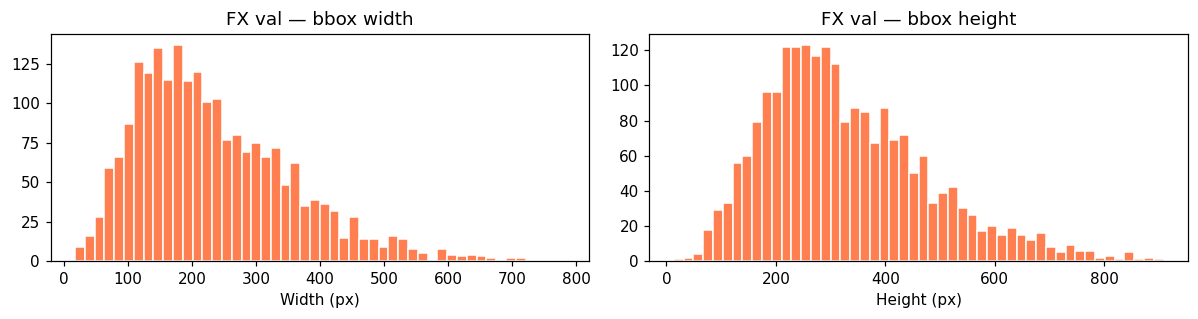

Width   mean=234.9  std=121.8
Height  mean=329.6  std=149.5


In [25]:
# Bounding box size distribution — val
bbox_widths, bbox_heights = [], []
for i in sample_idx:
    kp = np.asarray(val_anns[i]['keypoint'], dtype=np.float32)
    if kp.ndim == 4:
        kp = kp[0]
    mid = kp[kp.shape[0] // 2, :17]
    valid = mid[(mid[:, 0] > 0) & (mid[:, 1] > 0)]
    if len(valid) > 1:
        bbox_widths.append(valid[:, 0].max() - valid[:, 0].min())
        bbox_heights.append(valid[:, 1].max() - valid[:, 1].min())

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(bbox_widths,  bins=50, color='coral', edgecolor='white')
axes[0].set_xlabel('Width (px)');  axes[0].set_title(f'{APPARATUS} val — bbox width')
axes[1].hist(bbox_heights, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Height (px)'); axes[1].set_title(f'{APPARATUS} val — bbox height')
plt.tight_layout(); plt.show()
print(f'Width   mean={np.mean(bbox_widths):.1f}  std={np.std(bbox_widths):.1f}')
print(f'Height  mean={np.mean(bbox_heights):.1f}  std={np.std(bbox_heights):.1f}')

---
## 6. Motion Analysis — Val

In [ ]:
sub = X_val  # full val set

dx = np.abs(np.diff(sub[:, 0, :, :, 0], axis=1))
dy = np.abs(np.diff(sub[:, 1, :, :, 0], axis=1))
vel = (dx + dy).mean(axis=(0, 1))

colors_v = ['#d65f5f' if v > np.percentile(vel, 75) else
             '#4878cf' if v < np.percentile(vel, 25) else
             'coral' for v in vel]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(18), vel, color=colors_v)
ax.set_xticks(range(18))
ax.set_xticklabels(COCO18_NAMES, rotation=45, ha='right')
ax.set_ylabel('Mean absolute velocity (pixels/frame)')
ax.set_title(f'{APPARATUS} val — per-joint velocity (n={len(X_val)}, red=most active, blue=least active)')
plt.tight_layout(); plt.show()

sorted_joints = np.argsort(vel)[::-1]
print('Most  active:', [COCO18_NAMES[j] for j in sorted_joints[:5]])
print('Least active:', [COCO18_NAMES[j] for j in sorted_joints[-5:]])

In [ ]:
xy           = X_val[:, :, :, :, 0]                 # full set
is_zero      = (xy[:, 0] == 0) & (xy[:, 1] == 0)
zero_frac    = is_zero.mean(axis=(1, 2))
total_motion = (dx + dy).mean(axis=(1, 2))

valid = zero_frac < 0.05
print(f'Samples with >5% zero keypoints: {(~valid).sum()}/{len(valid)} '
      f'({(~valid).mean():.1%})')
print(f'Valid samples  motion  mean={total_motion[valid].mean():.1f}  '
      f'std={total_motion[valid].std():.1f}  '
      f'min={total_motion[valid].min():.1f}  max={total_motion[valid].max():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(zero_frac, bins=60, color='coral', edgecolor='none')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='5% threshold')
ax.set_xlabel('Fraction of zero keypoints per sample')
ax.set_ylabel('# samples')
ax.set_title(f'{APPARATUS} val — zero keypoint fraction (n={len(X_val)})')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(total_motion[valid],  bins=60, color='coral',  edgecolor='none',
        alpha=0.85, label=f'valid (n={valid.sum()})')
ax.hist(total_motion[~valid], bins=60, color='tomato', edgecolor='none',
        alpha=0.85, label=f'corrupt (n={(~valid).sum()})')
ax.set_xlabel('Mean per-frame joint displacement (px)')
ax.set_ylabel('# samples')
ax.set_title(f'{APPARATUS} val — displacement split by validity')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(zero_frac[valid],  total_motion[valid],  s=6, alpha=0.3,
           color='coral',  label='valid')
ax.scatter(zero_frac[~valid], total_motion[~valid], s=6, alpha=0.5,
           color='tomato', label='corrupt')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.set_xlabel('Zero keypoint fraction')
ax.set_ylabel('Mean displacement (px)')
ax.set_title(f'{APPARATUS} val — zero fraction vs displacement')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

class_motion = {c: total_motion[(y_val == c) & valid].mean()
                for c in np.unique(y_val)
                if ((y_val == c) & valid).sum() > 1}
sorted_by_motion = sorted(class_motion.items(), key=lambda x: x[1], reverse=True)
n_show = min(10, len(sorted_by_motion))
top_n, bot_n = sorted_by_motion[:n_show], sorted_by_motion[-n_show:]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh([f'cls {c}' for c, _ in top_n], [v for _, v in top_n], color='#d65f5f')
axes[0].set_xlabel('Mean displacement (px)'); axes[0].set_title(f'Top {n_show} most dynamic')
axes[1].barh([f'cls {c}' for c, _ in bot_n], [v for _, v in bot_n], color='#4878cf')
axes[1].set_xlabel('Mean displacement (px)'); axes[1].set_title(f'Top {n_show} least dynamic')
plt.suptitle(f'{APPARATUS} val — most/least dynamic classes (valid only)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Class Separability — PCA & t-SNE (Val)

In [ ]:
feats     = X_val[:, :, :, :, 0].mean(axis=2).reshape(len(X_val), -1)  # (N, 36)
lbls_tsne = y_val

n_top = min(20, num_classes)
top_classes = [c for c, _ in Counter(lbls_tsne.tolist()).most_common(n_top)]
mask_top    = np.isin(lbls_tsne, top_classes)
feats_top   = feats[mask_top]
lbls_top    = lbls_tsne[mask_top]

pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(feats_top)

cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(top_classes):
    m = lbls_top == c
    ax.scatter(pca_coords[m, 0], pca_coords[m, 1],
               s=12, alpha=0.5, color=cmap(i / n_top), label=f'cls {c}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'PCA — {APPARATUS} val (top {n_top} classes, n={mask_top.sum()})')
ax.legend(ncol=4, fontsize=7, markerscale=2)
plt.tight_layout(); plt.show()
print(f'PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}  '
      f'cumulative={pca.explained_variance_ratio_.sum():.1%}')

Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


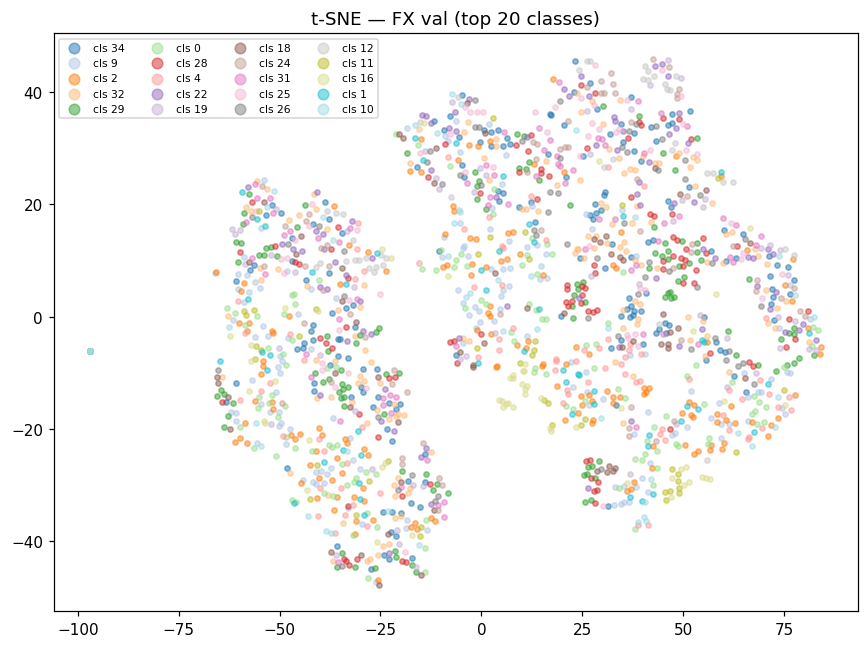

In [29]:
print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=min(30, len(feats_top) // 4),
            random_state=SEED, n_iter=1000)
tsne_coords = tsne.fit_transform(feats_top)

fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(top_classes):
    m = lbls_top == c
    ax.scatter(tsne_coords[m, 0], tsne_coords[m, 1],
               s=12, alpha=0.5, color=cmap(i / n_top), label=f'cls {c}')
ax.set_title(f't-SNE — {APPARATUS} val (top {n_top} classes)')
ax.legend(ncol=4, fontsize=7, markerscale=2)
plt.tight_layout(); plt.show()

---
## 8. Sample Visualization — Val

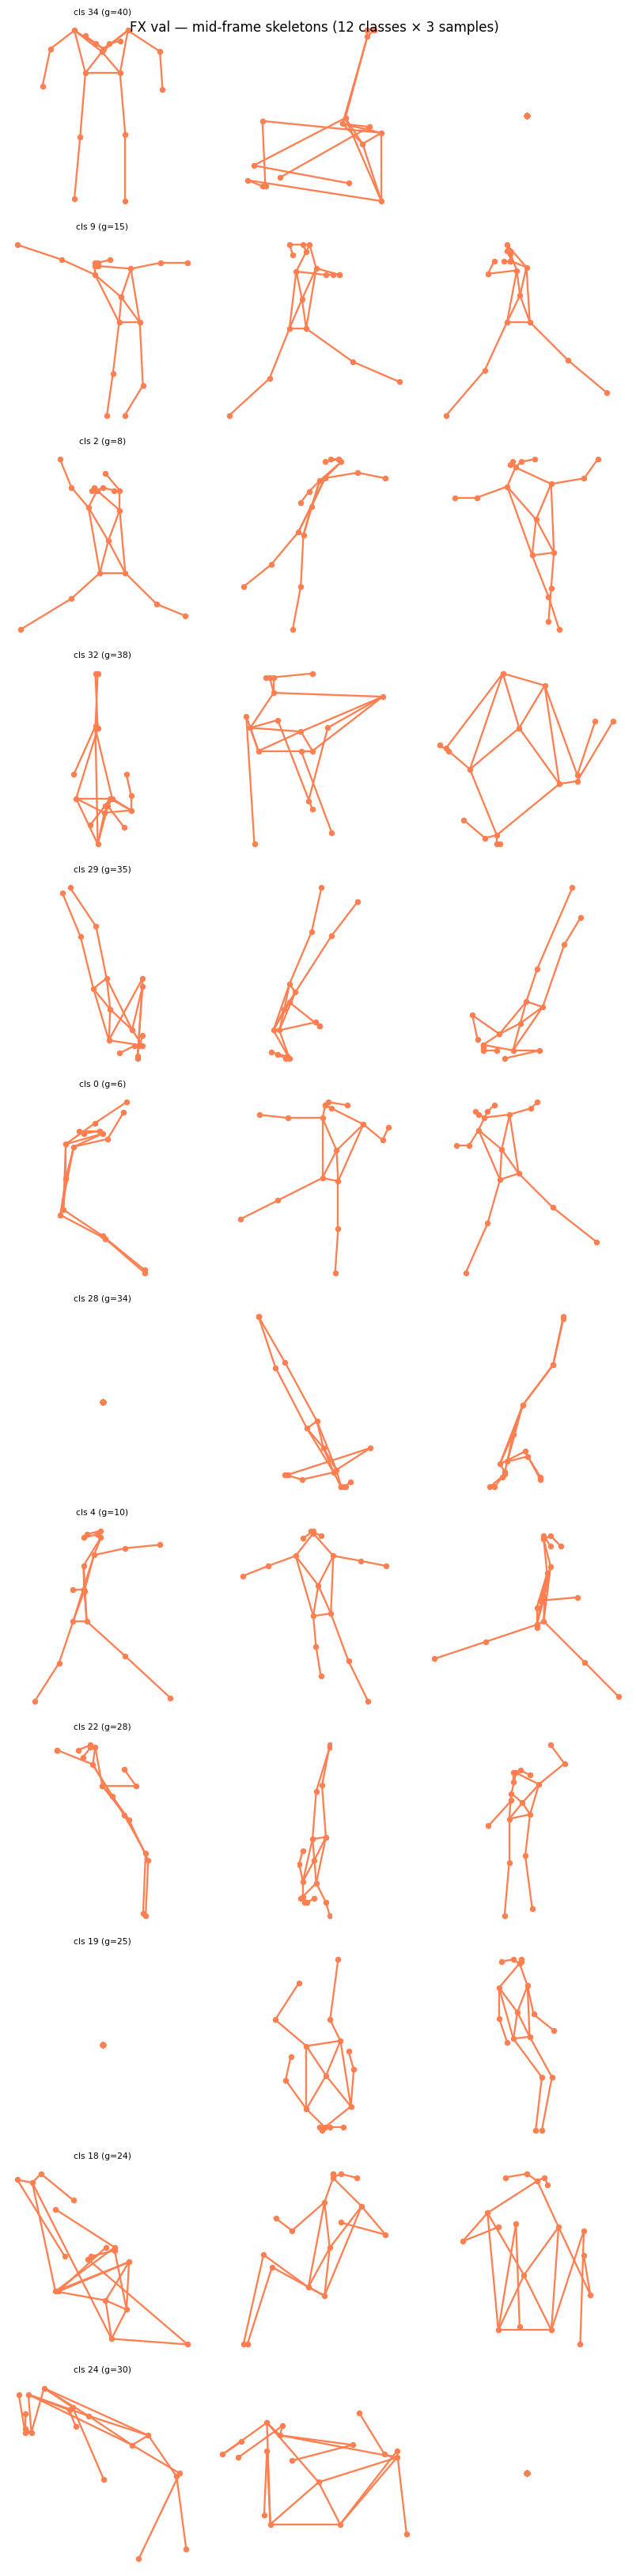

In [30]:
from src.joint_specs import get_joint_spec

spec = get_joint_spec('coco18')

def draw_skeleton(ax, tensor_sample, t, bone_pairs, color='coral', title=''):
    xy = np.stack([tensor_sample[0, t, :, 0],
                   tensor_sample[1, t, :, 0]], axis=1)
    for p, c in bone_pairs:
        ax.plot([xy[p, 0], xy[c, 0]], [xy[p, 1], xy[c, 1]], color=color, lw=1.5)
    ax.scatter(xy[:, 0], xy[:, 1], s=15, color=color, zorder=5)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(title, fontsize=7)

N_SHOW_CLASSES = min(num_classes, 12)
show_classes   = [c for c, _ in Counter(y_val.tolist()).most_common(N_SHOW_CLASSES)]
N_PER_CLASS    = 3
mid_t          = X_val.shape[2] // 2

fig, axes = plt.subplots(N_SHOW_CLASSES, N_PER_CLASS,
                         figsize=(N_PER_CLASS * 2.5, N_SHOW_CLASSES * 2.5))
if N_SHOW_CLASSES == 1:
    axes = axes[np.newaxis, :]

for row, cls in enumerate(show_classes):
    cls_idx = np.where(y_val == cls)[0]
    picks   = rng.choice(cls_idx, min(N_PER_CLASS, len(cls_idx)), replace=False)
    for col in range(N_PER_CLASS):
        ax = axes[row, col]
        if col < len(picks):
            global_lbl = cls + apparatus_label_offset
            title = f'cls {cls} (g={global_lbl})' if col == 0 else ''
            draw_skeleton(ax, X_val[picks[col]], mid_t, spec.bone_pairs,
                          color='coral', title=title)
        else:
            ax.axis('off')

fig.suptitle(f'{APPARATUS} val — mid-frame skeletons ({N_SHOW_CLASSES} classes × {N_PER_CLASS} samples)',
             fontsize=11)
plt.tight_layout()
plt.show()

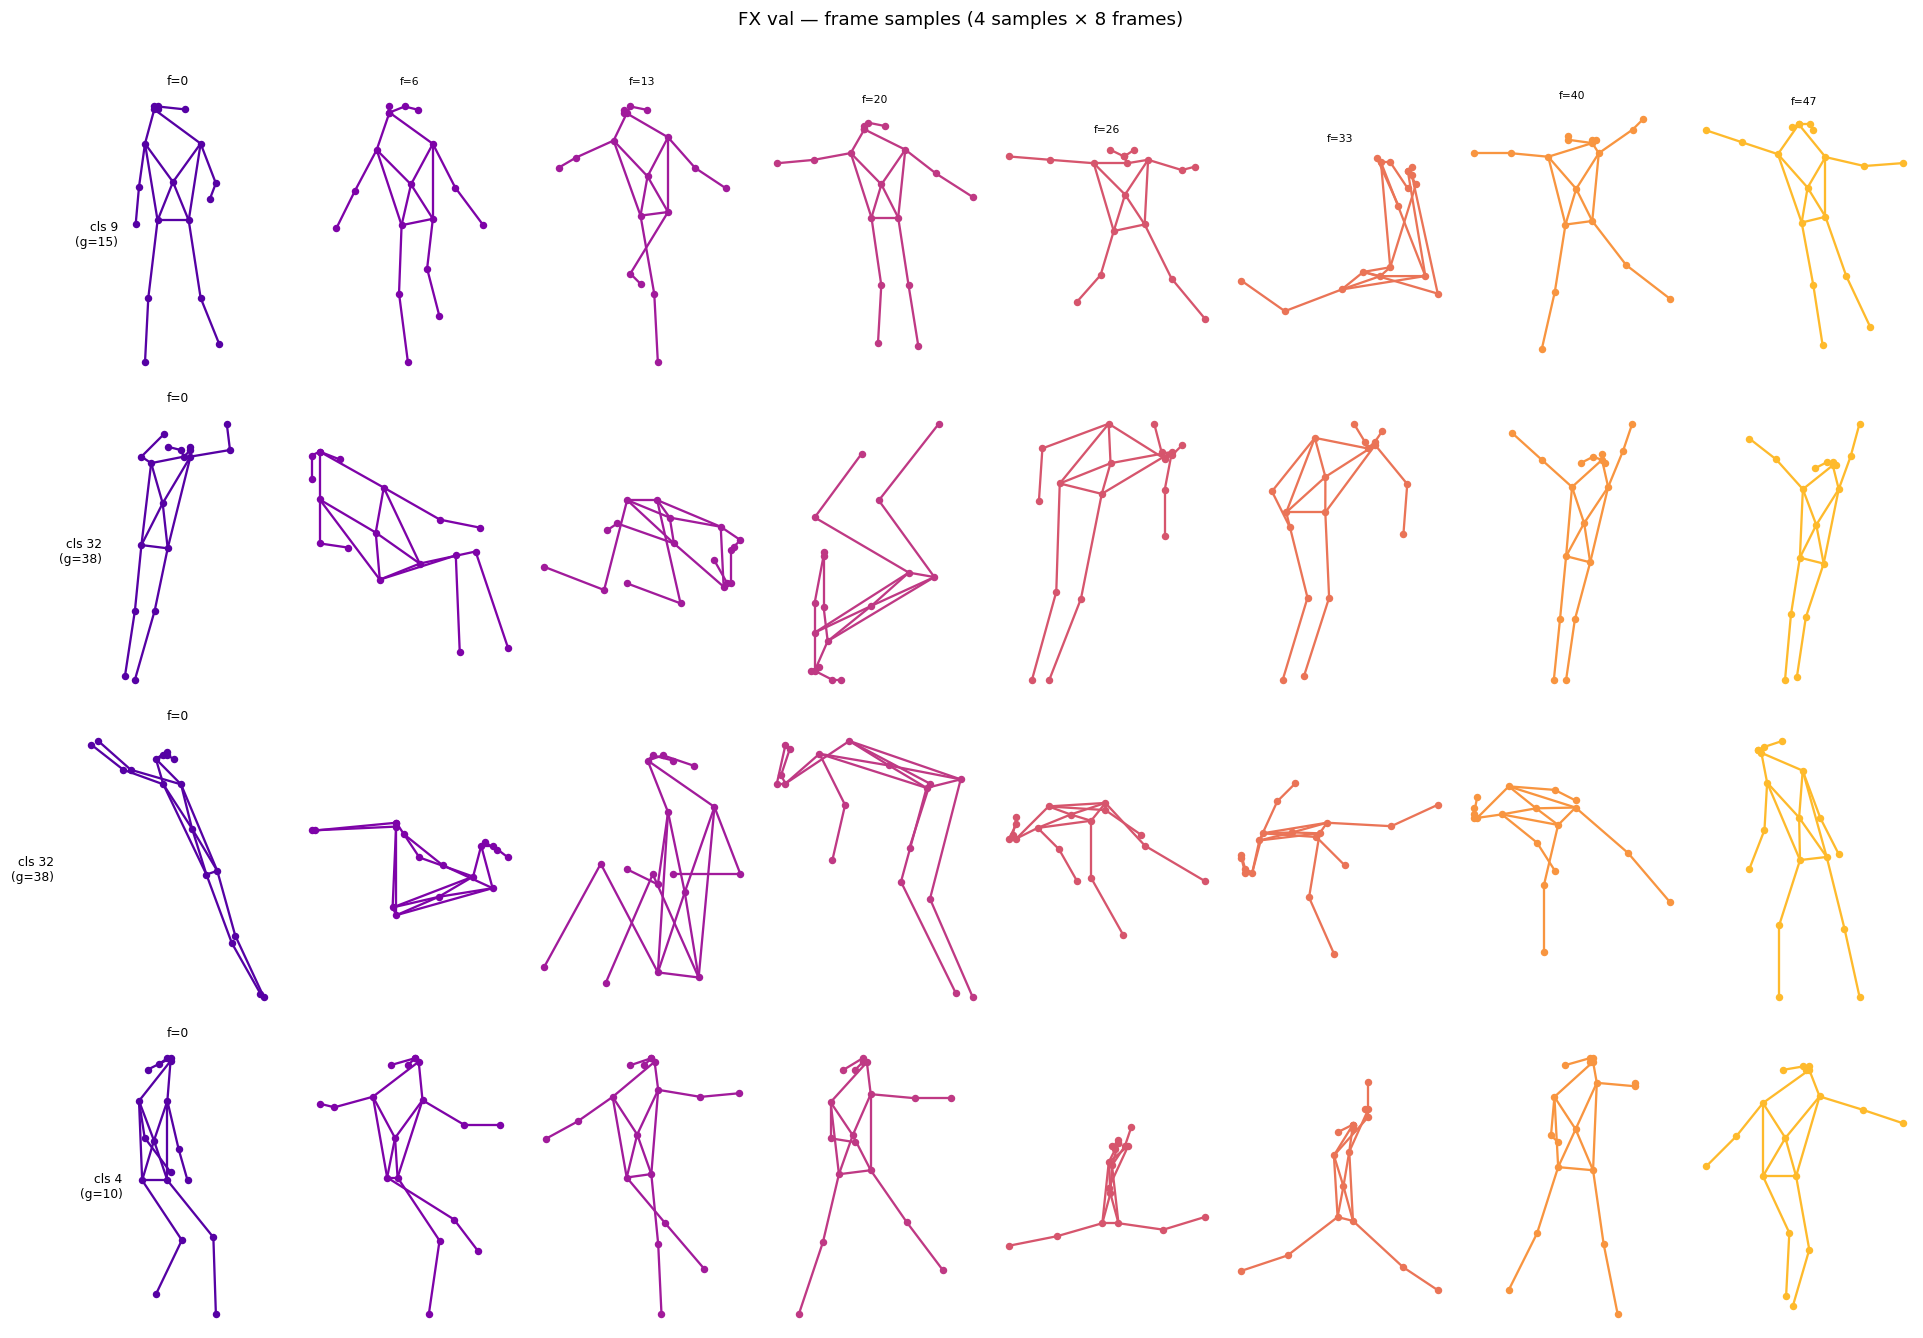

In [31]:
N_SAMPLES   = 4
N_FRAMES    = 8
T           = X_val.shape[2]
frame_ticks = np.linspace(0, T - 1, N_FRAMES, dtype=int)
strip_idx   = rng.choice(len(X_val), N_SAMPLES, replace=False)

fig, axes = plt.subplots(N_SAMPLES, N_FRAMES, figsize=(N_FRAMES * 2.2, N_SAMPLES * 3.0))
cmap_t = plt.cm.plasma(np.linspace(0.15, 0.85, N_FRAMES))

for row, si in enumerate(strip_idx):
    cls        = int(y_val[si])
    global_lbl = cls + apparatus_label_offset
    for col, t in enumerate(frame_ticks):
        ax = axes[row, col]
        draw_skeleton(ax, X_val[si], t, spec.bone_pairs,
                      color=cmap_t[col],
                      title=f'f={t}' if row == 0 else '')
        if col == 0:
            ax.set_title(f'f={t}', fontsize=8)
            ax.text(-0.15, 0.5, f'cls {cls}\n(g={global_lbl})',
                    transform=ax.transAxes, fontsize=8,
                    va='center', ha='right')

fig.suptitle(f'{APPARATUS} val — frame samples ({N_SAMPLES} samples × {N_FRAMES} frames)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Sample GIF — Val
Change `GIF_CLASS` and `GIF_SAMPLE_IDX` to pick a specific val sample.

Action: switch leap with 0.5 turn
File:   FX_val_g6_switch_leap_with_0_5_turn.gif
Saved (48 frames @ 10 fps)


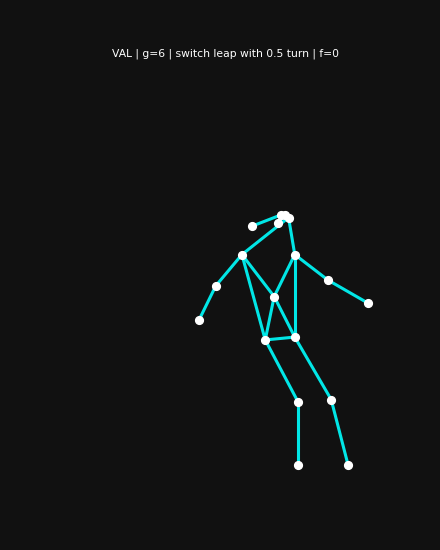

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import re
import urllib.request
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display as ipy_display
from src.config import GYM99_CATEGORIES_URL

# ── Config ────────────────────────────────────────────────────
GIF_CLASS      = 0
GIF_SAMPLE_IDX = 0
GIF_FPS        = 10
# ─────────────────────────────────────────────────────────────

def load_gym99_names(url):
    text = urllib.request.urlopen(url).read().decode('utf-8')
    names = {}
    for line in text.splitlines():
        if 'Clabel:' not in line or 'Glabel:' not in line:
            continue
        try:
            clabel = int(line.split('Clabel:')[1].split(';')[0].strip())
            name   = re.sub(r'^\(\w+\)\s*', '', line.split(';')[-1].strip())
            names[clabel] = name
        except Exception:
            continue
    return names

gym99_names = load_gym99_names(GYM99_CATEGORIES_URL)

cls_indices = np.where(y_val == GIF_CLASS)[0]
if len(cls_indices) == 0:
    raise ValueError(f'Class {GIF_CLASS} not found in val set.')
si          = cls_indices[GIF_SAMPLE_IDX % len(cls_indices)]
sample      = X_val[si]
T_frames    = sample.shape[1]
global_lbl  = GIF_CLASS + apparatus_label_offset
action_name = gym99_names.get(global_lbl, f'class_{global_lbl}')

safe_name = re.sub(r'[^a-zA-Z0-9]+', '_', action_name).strip('_')[:60]
GIF_PATH  = f'{APPARATUS}_val_g{global_lbl}_{safe_name}.gif'
print(f'Action: {action_name}')
print(f'File:   {GIF_PATH}')

pad  = 20
xlim = (sample[0, :, :, 0].min() - pad, sample[0, :, :, 0].max() + pad)
ylim = (sample[1, :, :, 0].max() + pad, sample[1, :, :, 0].min() - pad)

fig, ax = plt.subplots(figsize=(4, 5))
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
cmap_gif = plt.cm.cool(np.linspace(0, 1, T_frames))

def update(t):
    ax.clear()
    ax.set_facecolor('#111111')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis('off')
    ax.set_title(f'VAL | g={global_lbl} | {action_name[:40]} | f={t}',
                 fontsize=7, color='white')
    xy = np.stack([sample[0, t, :, 0], sample[1, t, :, 0]], axis=1)
    for p, c in spec.bone_pairs:
        ax.plot([xy[p, 0], xy[c, 0]], [xy[p, 1], xy[c, 1]],
                color=cmap_gif[t], lw=2, alpha=0.9)
    ax.scatter(xy[:, 0], xy[:, 1], s=25, color='white', zorder=5)

anim = FuncAnimation(fig, update, frames=T_frames, interval=1000 // GIF_FPS)
anim.save(GIF_PATH, writer=PillowWriter(fps=GIF_FPS))
plt.close()
print(f'Saved ({T_frames} frames @ {GIF_FPS} fps)')
ipy_display(Image(GIF_PATH))

if IN_COLAB:
    from google.colab import files
    files.download(GIF_PATH)